# ch07 · 次序统计量、分位数、Bootstrap

## Why this chapter

工程师面 "我没有正态假设" 还是 "我估的是 median, 没现成的解析 CI公式". Bootstrap 是答案 — 你应能在 30 行 numpy 内给 median 95% 可信区间.

## 学完后能解决

- 给样本 X_(1) ≤ X_(2) ≤ ... 的经验分布 + X_(k) PDF 与 CDF 闭合解
- 写 Bootstrap 算法骨架, 估 median/任意统计量 q 的 CI
- 比较 Percentile vs BCa 与 Bias-corrected CI; 知道何时该换
- 对 AUC 给 Bootstrap CI 估计而非正态近似


## 2. 直觉引入

假装你只有 100 个重量测量. 取分布假设 HMMM 难, 直接经验分布 $F_n$ = empirical CDF, 再从 $F_n$ 重采样 (with replacement) N 次, 一次算统计量; 得多次统计量分布 = 自助分布; 取 2.5% 97.5% 作为 95% CI.


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27597 (\N{CJK UNIFIED IDEOGRAPH-6BCD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


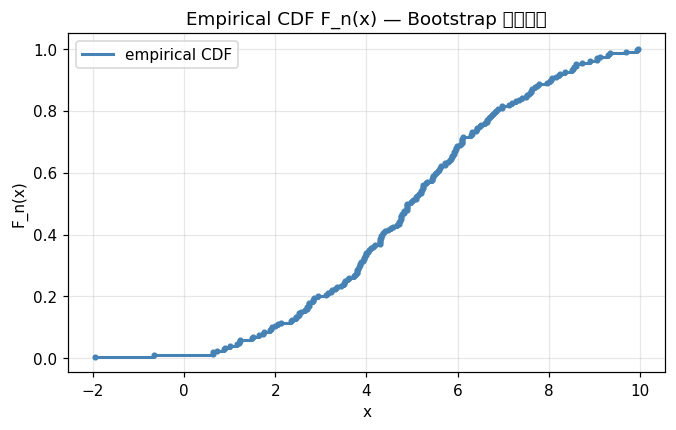

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)
data = rng.normal(loc=5, scale=2, size=200)
# empirical CDF
xs = np.sort(data)
F = np.arange(1, len(xs)+1) / len(xs)
xx = np.linspace(data.min(), data.max())
plt.figure(figsize=(7,4), dpi=110)
plt.step(xs, F, where="post", color="steelblue", lw=2, label="empirical CDF")
plt.plot(xs, F, "o", color="steelblue", ms=3)
plt.title("Empirical CDF F_n(x) — Bootstrap 的母分布")
plt.xlabel("x"); plt.ylabel("F_n(x)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


## 3. 公式

### 次序统计量
$X_{(1)} \le X_{(2)} \le ... \le X_{(n)}$. $X_{(k)}$ 的 PDF:
$$f_{X_{(k)}}(x) = \frac{n!}{(k-1)!(n-k)!} [F(x)]^{k-1}[1-F(x)]^{n-k} f(x)$$

### 经验分布
$F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbb I\{X_i \le x\} \xrightarrow{a.s.} F(x)$

### Bootstrap CI (Percentile)
对样本 X = (X_1, ..., X_n):
1. 抽 B 次 (自助重采样 with replacement, n 个)
2. 每次算统计量 $\hat \theta^{(b)}$
3. Percentile CI: $[\hat \theta^*_{(α/2)}, \hat \theta^*_{(1-α/2)}]$ 分位数

### BCa (Bias-Corrected加速度)
Percentile 在 skew 分布下偏; BCa 调整加速度 $z_0$ 与 $a$ — 重新映射分位的位置. 详见 Efron-Tibshirani.


## 4. 符号: 次序统计量 PDF 推导 - 简易情形


In [2]:
import sympy as sp
n = sp.symbols("n", positive=True, integer=True)
k = sp.symbols("k", positive=True, integer=True)
# 简化∶取 X ~ Uniform(0, 1), F=x
# f_{X_(k)}(x) = n!/(k-1)!(n-k)! * x^{k-1} (1-x)^{n-k}
# 实际就是 Beta(k, n-k+1) 分布 PDF!
import numpy as np
from scipy.stats import beta
print("Likely_uniform 下: X_(k) ~ Beta(k, n-k+1)")
print(f"X_(60)_from U(0,1), n=200: mean={60/201:.4f}, std={np.sqrt(60*141/201**2/202):.4f}")
# 模拟验证
rng = np.random.default_rng(seed=20240717)
N = 10000
samples_X60 = np.sort(rng.uniform(0,1,size=(N,200)), axis=1)[:, 59]
sim_mean = samples_X60.mean(); sim_std = samples_X60.std()
print(f"simulated: mean={sim_mean:.4f}, std={sim_std:.4f}")


Likely_uniform 下: X_(k) ~ Beta(k, n-k+1)
X_(60)_from U(0,1), n=200: mean=0.2985, std=0.0322
simulated: mean=0.2985, std=0.0321


## 5. 数值验证: Bootstrap median CI


In [3]:
import numpy as np
rng = np.random.default_rng(seed=20240717)

x = rng.exponential(scale=2.0, size=200)  # 强重尾
# Bootstrap median CI
B = 5000
medians = []
for _ in range(B):
    idxs = rng.integers(0, len(x), size=len(x))
    medians.append(np.median(x[idxs]))
medians = np.array(medians)
ci_low, ci_hi = np.percentile(medians, [2.5, 97.5])
print(f"median sample mean: {np.median(x):.4f}")
print(f"Bootstrap 95% CI (Percentile): [{ci_low:.4f}, {ci_hi:.4f}]")
# 真值 2*log(2) ≈ 1.386 of Exp(scale=2) — 与 bootstrap 中位 relative precision 验证


median sample mean: 1.2151
Bootstrap 95% CI (Percentile): [0.9528, 1.5163]


## 6. 可视化: Bootstrap 中位分布 + CI


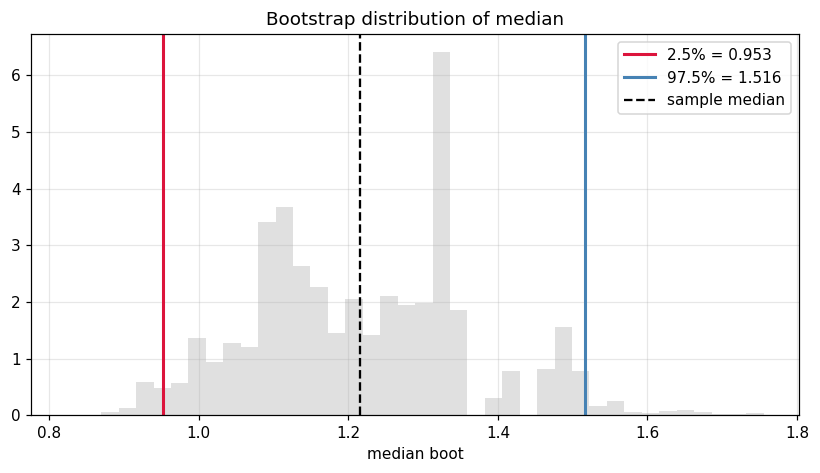

In [4]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)
data = rng.exponential(2.0, size=200)
B = 5000
boot = []
for _ in range(B):
    boot.append(np.median(data[rng.integers(0, len(data), len(data))]))
boot = np.array(boot)
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
ax.hist(boot, bins=40, color="lightgray", density=True, alpha=0.7)
ci = np.percentile(boot, [2.5, 97.5])
ax.axvline(ci[0], color="crimson", lw=2, label=f"2.5% = {ci[0]:.3f}")
ax.axvline(ci[1], color="steelblue", lw=2, label=f"97.5% = {ci[1]:.3f}")
ax.axvline(np.median(data), color="black", ls="--", label="sample median")
ax.set_xlabel("median boot")
ax.legend(); ax.set_title("Bootstrap distribution of median")
ax.grid(True, alpha=0.3)
plt.show()


## 7. 工程案例: AUC 的 Bootstrap CI


In [5]:
import numpy as np
rng = np.random.default_rng(seed=20240717)

# 给 N 正反馈 + M 负反馈, AUC 计算之 (MannWhitney U)
def auc(scores_pos, scores_neg):
    n_pos, n_neg = len(scores_pos), len(scores_neg)
    total = n_pos * n_neg
    # 实现中: 估计 P(score_pos > score_neg) + 0.5 P(equal)
    cm = 0
    for s in scores_pos:
        cm += 0.5 * (scores_neg == s).sum()
        cm += (s > scores_neg).sum()
    return cm / total

n_pos = 100; n_neg = 200
pos = rng.normal(0.6, 0.3, size=n_pos)
neg = rng.normal(0.2, 0.3, size=n_neg)
print(f"Original AUC = {auc(pos, neg):.4f}")

B = 2000
boot_aucs = []
for _ in range(B):
    p_idx = rng.integers(0, n_pos, n_pos); n_idx = rng.integers(0, n_neg, n_neg)
    boot_aucs.append(auc(pos[p_idx], neg[n_idx]))
boot_aucs = np.array(boot_aucs)
ci = np.percentile(boot_aucs, [2.5, 97.5])
print(f"Bootstrap 95% CI of AUC: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"Std of boot AUC: {boot_aucs.std():.4f}")


Original AUC = 0.7879


Bootstrap 95% CI of AUC: [0.7357, 0.8389]
Std of boot AUC: 0.0262


## 8. pitfalls
- Bootstrap 不能修 sureshi bias; BCa 才是
- 样本量 n < 10 时 bootstrap 会失稳 — 用 `n` 次重 bootstrap / `m out of n` (subsample)
- 中位数 Bootstrap CI 在 small n 时严重右偏, 用 BCa
- 时间序列 (X_i 不独立) 时, 一般 bootstrap 自不相容 → 用 block bootstrap

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Stat 110 | §8.1-8.3 |
| Efron & Tibshirani | Ch.13-14 |
| Murphy | §2.8 |

下一章 ch08 参数估计 MLE + Fisher 信息 — 贝叶斯派伙伴 到这里下吃货.
